**SETUP JAVA IN GOOGLE COLAB**

In [1]:
!apt update -q

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Building dependency tree...
Reading state information...
80 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
!apt-get install -q openjdk-11-jdk-headless

Reading package lists...
Building dependency tree...
Reading state information...
openjdk-11-jdk-headless is already the newest version (11.0.32+9-1ubuntu1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 80 not upgraded.


In [3]:
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharing)


In [4]:
!javac -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
javac 21.0.11


**STORING AND SECURING API KEY**

In [5]:
from getpass import getpass
import os

os.environ["TWELVE_DATA_API_KEY"] = getpass("Enter your Twelve Data API key: ")

Enter your Twelve Data API key: ··········


**CREATING JAVA APPLICATION CALLED APP.java**

In [19]:
%%writefile App.java

import java.net.URI;
import java.net.http.HttpClient;
import java.net.http.HttpRequest;
import java.net.http.HttpResponse;
import java.time.Instant;
import java.util.LinkedList;
import java.util.Queue;

public class App {

  
    private static Queue<PriceRecord> priceQueue = new LinkedList<>();

    public static void main(String[] args) {

        
        String apiKey = System.getenv("TWELVE_DATA_API_KEY");

        if (apiKey == null || apiKey.isEmpty()) {
            System.out.println("API key not found.");
            return;
        }

        HttpClient client = HttpClient.newHttpClient();

       
        for (int i = 0; i < 3; i++) {

            try {
                String url =
                    "https://api.twelvedata.com/price?symbol=DIA&apikey="
                    + apiKey;

                HttpRequest request = HttpRequest.newBuilder()
                        .uri(URI.create(url))
                        .GET()
                        .build();

                HttpResponse<String> response = client.send(
                        request,
                        HttpResponse.BodyHandlers.ofString()
                );

                
                String responseBody = response.body();

                String price = responseBody
                        .replaceAll(".*\"price\":\"([0-9.]+)\".*", "$1");

               
                String timestamp = Instant.now().toString();

                
                PriceRecord record = new PriceRecord(
                        Double.parseDouble(price),
                        timestamp
                );

                priceQueue.add(record);

                
                System.out.println(
                        "Added data point: price="
                        + record.getPrice()
                        + ", timestamp="
                        + record.getTimestamp()
                );

                
                if (i < 2) {
                    Thread.sleep(15000);
                }

            } catch (Exception e) {
                System.out.println("Error: " + e.getMessage());
            }
        }

        System.out.println();
        System.out.println("Data collection complete.");
        System.out.println("Total data points collected: "
                + priceQueue.size());
    }

    
    static class PriceRecord {

        private double price;
        private String timestamp;

        public PriceRecord(double price, String timestamp) {
            this.price = price;
            this.timestamp = timestamp;
        }

        public double getPrice() {
            return price;
        }

        public String getTimestamp() {
            return timestamp;
        }
    }
}

Overwriting App.java


**COMPILING & RUNNING THE APPLICATION**

In [20]:
import subprocess
import os

print("API key found:", bool(os.getenv("TWELVE_DATA_API_KEY")))

compile_result = subprocess.run(
    ["javac", "App.java"],
    capture_output=True,
    text=True
)

print("Compile return code:", compile_result.returncode)

if compile_result.stdout:
    print("Compile output:")
    print(compile_result.stdout)

if compile_result.stderr:
    print("Compile errors:")
    print(compile_result.stderr)

if compile_result.returncode == 0:
    run_result = subprocess.run(
        ["java", "App"],
        capture_output=True,
        text=True,
        env=os.environ
    )

    print("Run return code:", run_result.returncode)

    print("Application output:")
    print(run_result.stdout)

    if run_result.stderr:
        print("Application errors:")
        print(run_result.stderr)
else:
    print("Your Java file did not compile. Review the errors above before running the application.")

API key found: True
Compile return code: 0
Compile output:
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate

Run return code: 0
Application output:
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Added data point: price=534.070007, timestamp=2026-09-07T01:17:49.954135327Z
Added data point: price=534.070007, timestamp=2026-09-07T01:18:05.157082413Z
Added data point: price=534.070007, timestamp=2026-09-07T01:18:20.403813754Z

Data collec

**VISUALIZING DIA MARKET DATA USING PYTHON**

        price                           timestamp
0  534.070007 2026-09-07 01:17:49.954135327+00:00
1  534.070007 2026-09-07 01:18:05.157082413+00:00
2  534.070007 2026-09-07 01:18:20.403813754+00:00


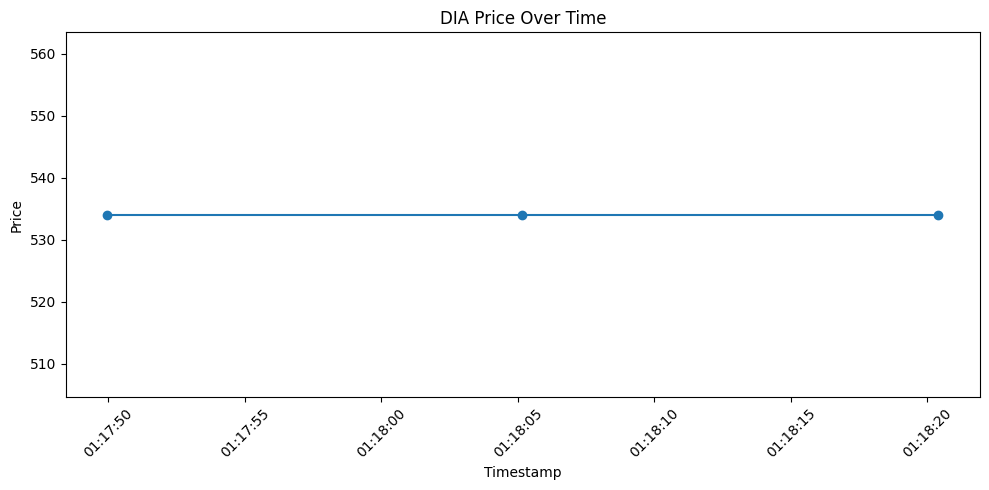

In [21]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Paste your Java output between the triple quotes below
java_output = """
Added data point: price=534.070007, timestamp=2026-09-07T01:17:49.954135327Z
Added data point: price=534.070007, timestamp=2026-09-07T01:18:05.157082413Z
Added data point: price=534.070007, timestamp=2026-09-07T01:18:20.403813754Z
"""

# Extract price and timestamp
matches = re.findall(
    r"price=([0-9.]+), timestamp=([^\n]+)",
    java_output
)

# Convert to DataFrame
df = pd.DataFrame(matches, columns=["price", "timestamp"])

# Convert data types
df["price"] = df["price"].astype(float)
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df["timestamp"], df["price"], marker="o")

plt.title("DIA Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()